# Indice Synthétique de Convergence Technologique

Ce notebook construit l'indice synthétique à partir des 4 composantes :
- **C1** : Proximité directe (Jaccard)
- **C2** : Dynamique temporelle (corrélation glissante)
- **C3** : Centralité croisée (moyenne géométrique des Strength normalisés)
- **C4** : Co-appartenance à un cluster absorbant

L'unité d'analyse est la **paire (cpc_i, cpc_j, année)**.

L'agrégation finale se fait par **PCA à 1 composante** (approche data-driven, sans pondération arbitraire),
avec validation sur deux cas connus :
- C12N × A61K (biotechnologie → biopharmacie, convergence attendue après 1995)
- H01M × B60L (batteries × propulsion électrique, convergence attendue après 2012)

## 0. Imports et chargement des données

In [1]:
!pip install networkx

In [2]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter, defaultdict
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── paramètres globaux ──────────────────────────────────────────────────────
WINDOW      = 5    # taille des fenêtres glissantes (années)
K_CLUSTERS  = 10   # nombre de clusters k-means
N_PCA_CLUST = 20   # composantes PCA pour le clustering
CORR_WINDOW = 5    # fenêtre corrélation glissante
EPS         = 1e-10
MIN_PATENTS = 30   # filtre de stabilité : nb min de brevets/an pour une paire
YEAR_START  = 1980
YEAR_END    = 2023

In [3]:
# ── chargement ──────────────────────────────────────────────────────────────
# Le parquet contient au minimum : publication_date, cpc4_list
df_raw = pd.read_parquet("multi_codes_brevets.parquet")
df_raw = df_raw.dropna(subset=["year", "cpc4_list"]).copy()
df_raw["year"] = df_raw["year"].astype(int)

def normalize_cpc_list(lst):
    """Conserve les 4 premiers caractères, déduplique, trie."""
    clean = []
    for c in lst:
        if c is None: continue
        s = str(c).upper().strip()
        if len(s) >= 3:
            clean.append(s[:4])
    return sorted(set(clean))

df_raw["cpc4"] = df_raw["cpc4_list"].apply(normalize_cpc_list)
df_raw = df_raw[df_raw["cpc4"].apply(len) >= 2].copy()

# pondération annuelle (correction du volume de brevets)
brevet_count_by_year = df_raw.groupby("year").size().to_dict()
N_mean = np.mean(list(brevet_count_by_year.values()))

print(f"Brevets chargés : {len(df_raw):,}")
print(f"Période : {df_raw['year'].min()} – {df_raw['year'].max()}")

Brevets chargés : 1,234,382
Période : 1980 – 2025


---
## C1 — Jaccard & probabilités conditionnelles

Pour chaque paire (i, j) et chaque année t, on calcule :
- **Jaccard** = |brevets avec i ET j| / |brevets avec i OU j|
- **P(j|i)** = |brevets avec i ET j| / |brevets avec i|
- **P(i|j)** = |brevets avec i ET j| / |brevets avec j|

On travaille sur des fenêtres glissantes de `WINDOW` ans (lissage).
La composante C1 retenue est le **Jaccard lissé** (symétrique, borné entre 0 et 1).

In [4]:
def compute_jaccard_yearly(df, window=WINDOW, min_patents=MIN_PATENTS):
    """
    Calcule l'indice de Jaccard et les probabilités conditionnelles
    pour toutes les paires actives, par fenêtre glissante.

    Retourne un DataFrame (cpc_i, cpc_j, year, jaccard, p_j_given_i, p_i_given_j)
    où year est le centre de la fenêtre.
    """
    years = sorted(df["year"].unique())
    records = []

    for t_center in years:
        t_start = t_center - window // 2
        t_end   = t_center + window // 2
        df_w = df[(df["year"] >= t_start) & (df["year"] <= t_end)]

        # comptages
        n_i     = Counter()   # brevets contenant i
        n_ij    = Counter()   # brevets contenant i ET j

        for _, row in df_w.iterrows():
            codes = row["cpc4"]
            for c in codes:
                n_i[c] += 1
            for ci, cj in itertools.combinations(codes, 2):
                key = (min(ci, cj), max(ci, cj))
                n_ij[key] += 1

        # calcul des métriques
        for (ci, cj), count_ij in n_ij.items():
            ni, nj = n_i[ci], n_i[cj]
            # filtre de stabilité
            if ni < min_patents or nj < min_patents:
                continue
            union = ni + nj - count_ij
            jaccard   = count_ij / union if union > 0 else 0
            p_j_gi    = count_ij / ni    if ni > 0   else 0
            p_i_gj    = count_ij / nj    if nj > 0   else 0
            records.append({
                "cpc_i": ci, "cpc_j": cj, "year": t_center,
                "jaccard": jaccard,
                "p_j_given_i": p_j_gi,
                "p_i_given_j": p_i_gj,
                "n_cooc": count_ij
            })

    return pd.DataFrame(records)


print("Calcul de C1 (Jaccard)...")
df_jaccard = compute_jaccard_yearly(df_raw)
print(f"  → {len(df_jaccard):,} observations (paire × année)")
df_jaccard.head()

Calcul de C1 (Jaccard)...
  → 1,382,733 observations (paire × année)


,cpc_i,cpc_j,year,jaccard,p_j_given_i,p_i_given_j,n_cooc
0,A61P,C07D,1980,0.416274,0.732365,0.490960,353
1,H01L,Y10S,1980,0.056604,0.344262,0.063444,42
2,B01J,C07F,1980,0.010610,0.017021,0.027397,4
3,B01J,C08G,1980,0.014463,0.029787,0.027344,7
4,C07C,Y02P,1980,0.108597,0.141732,0.317181,72


---
## C2 — Corrélation temporelle glissante

Pour chaque paire (i, j), on construit deux séries temporelles (le nombre de co-occurrences
de i avec l'ensemble du réseau chaque année, et idem pour j), puis on calcule la corrélation
de Pearson sur une fenêtre glissante.

Une corrélation élevée et **stable** → les deux domaines évoluent en synchronie → signal de convergence.

In [5]:
def build_activity_series(df):
    """
    Pour chaque code CPC4 et chaque année, calcule le nombre total
    de co-occurrences pondérées avec tous ses voisins.
    Retourne un DataFrame (cpc4, year, activity).
    """
    records = []
    for year, grp in df.groupby("year"):
        N_year = brevet_count_by_year[year]
        w_year = N_mean / N_year
        activity = defaultdict(float)
        for _, row in grp.iterrows():
            codes = row["cpc4"]
            m = len(codes)
            if m < 2: continue
            w_pair = (2.0 / (m * (m - 1))) * w_year
            for c in codes:
                activity[c] += w_pair * (m - 1)
        for cpc, val in activity.items():
            records.append({"cpc4": cpc, "year": year, "activity": val})
    return pd.DataFrame(records)


def compute_rolling_corr_all_pairs(df_jaccard, df_activity, window=CORR_WINDOW):
    """
    Pour chaque paire active dans df_jaccard, calcule la corrélation
    glissante entre les séries d'activité des deux codes.

    Retourne un DataFrame (cpc_i, cpc_j, year, rolling_corr).
    """
    # pivot : (year × cpc4) pour accès rapide
    pivot = df_activity.pivot(index="year", columns="cpc4", values="activity").fillna(0)
    all_years = sorted(pivot.index)

    # paires uniques
    pairs = df_jaccard[["cpc_i", "cpc_j"]].drop_duplicates().values.tolist()

    records = []
    for ci, cj in pairs:
        if ci not in pivot.columns or cj not in pivot.columns:
            continue
        s1 = pivot[ci]
        s2 = pivot[cj]
        corr = s1.rolling(window, min_periods=3).corr(s2)
        for yr, val in corr.items():
            if not np.isnan(val):
                records.append({"cpc_i": ci, "cpc_j": cj, "year": yr, "rolling_corr": val})

    return pd.DataFrame(records)


print("Construction des séries d'activité...")
df_activity = build_activity_series(df_raw)

print("Calcul de C2 (corrélation glissante)...")
df_corr = compute_rolling_corr_all_pairs(df_jaccard, df_activity)
print(f"  → {len(df_corr):,} observations (paire × année)")
df_corr.head()

Construction des séries d'activité...
Calcul de C2 (corrélation glissante)...
  → 3,507,315 observations (paire × année)


,cpc_i,cpc_j,year,rolling_corr
0,A61P,C07D,1982,0.635334
1,A61P,C07D,1983,0.348395
2,A61P,C07D,1984,0.431103
3,A61P,C07D,1985,0.986502
4,A61P,C07D,1986,0.997572


---
## C3 — Centralité croisée

On utilise les résultats de centralité déjà calculés (`centrality_results.csv`).

Pour une paire (i, j) à l'année t, on définit :

$$C3_{i,j,t} = \sqrt{\text{strength\_norm}(i,t) \times \text{strength\_norm}(j,t)}$$

La moyenne géométrique pénalise les paires où l'un des deux domaines est périphérique
(une convergence entre un code central et un code marginal est moins significative).

In [6]:
# ── chargement et normalisation de la centralité ────────────────────────────
centrality_df = pd.read_csv("centrality_results.csv")

if "t_center" not in centrality_df.columns:
    centrality_df["t_center"] = (
        centrality_df["window_start"] + centrality_df["window_end"]
    ) / 2.0

# arrondi à l'année entière
centrality_df["year"] = centrality_df["t_center"].round().astype(int)

# normalisation min-max du strength par année
scaler = MinMaxScaler()
centrality_df["strength_norm"] = (
    centrality_df
    .groupby("year")["strength"]
    .transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())
)

# dictionnaire d'accès rapide : (cpc4, year) → strength_norm
strength_lookup = (
    centrality_df
    .set_index(["cpc4", "year"])["strength_norm"]
    .to_dict()
)


def compute_cross_centrality(df_jaccard, strength_lookup):
    """
    Pour chaque paire (cpc_i, cpc_j, year), calcule la moyenne géométrique
    des strengths normalisés des deux codes.
    """
    df = df_jaccard[["cpc_i", "cpc_j", "year"]].copy()
    df["s_i"] = df.apply(
        lambda r: strength_lookup.get((r["cpc_i"], r["year"]), np.nan), axis=1
    )
    df["s_j"] = df.apply(
        lambda r: strength_lookup.get((r["cpc_j"], r["year"]), np.nan), axis=1
    )
    # moyenne géométrique
    df["cross_centrality"] = np.sqrt(df["s_i"] * df["s_j"])
    return df[["cpc_i", "cpc_j", "year", "cross_centrality"]]


print("Calcul de C3 (centralité croisée)...")
df_centrality_cross = compute_cross_centrality(df_jaccard, strength_lookup)
print(f"  → {df_centrality_cross['cross_centrality'].notna().sum():,} valeurs non-NaN")
df_centrality_cross.head()

Calcul de C3 (centralité croisée)...
  → 1,285,961 valeurs non-NaN


,cpc_i,cpc_j,year,cross_centrality
0,A61P,C07D,1980,NaN
1,H01L,Y10S,1980,NaN
2,B01J,C07F,1980,NaN
3,B01J,C08G,1980,NaN
4,C07C,Y02P,1980,NaN


---
## C4 — Co-appartenance à un cluster absorbant

Pour chaque paire (i, j) et chaque période, on vérifie :
1. Les deux codes appartiennent-ils au **même cluster** ?
2. Ce cluster a-t-il un **score d'absorption supérieur au 75e percentile** ?

Si oui → C4 = score d'absorption du cluster (valeur continue, pas binaire)
Si non → C4 = 0

In [7]:
# ── recalcul du clustering et du score d'absorption ─────────────────────────
# (reprend exactement la logique du notebook principal)

from collections import Counter

def build_cooc_matrix(df, year_start, year_end):
    df_w = df[(df["year"] >= year_start) & (df["year"] <= year_end)]
    df_w = df_w[df_w["cpc4"].apply(lambda x: len(x) >= 2)]
    pair_counter = Counter()
    for cpcs in df_w["cpc4"]:
        cpcs_u = sorted(set(cpcs))
        for ci, cj in itertools.combinations(cpcs_u, 2):
            pair_counter[(ci, cj)] += 1
            pair_counter[(cj, ci)] += 1
    cooc = pd.DataFrame(
        [(i, j, c) for (i, j), c in pair_counter.items()],
        columns=["cpc_i", "cpc_j", "count"]
    )
    row_sums = cooc.groupby("cpc_i")["count"].sum().rename("row_sum")
    cooc = cooc.join(row_sums, on="cpc_i")
    cooc["M_ij"] = cooc["count"] / cooc["row_sum"]
    return cooc


print("Calcul du clustering dynamique (fenêtres annuelles)...")
pca_clust  = PCA(n_components=N_PCA_CLUST, random_state=0)
kmeans_obj = KMeans(n_clusters=K_CLUSTERS, random_state=0, n_init=10)

cluster_time = []
for start in range(YEAR_START, YEAR_END - WINDOW + 2):
    end = start + WINDOW - 1
    cooc_w = build_cooc_matrix(df_raw, start, end)
    if len(cooc_w) == 0:
        continue
    M_w = cooc_w.pivot(index="cpc_i", columns="cpc_j", values="M_ij").fillna(0)
    if M_w.shape[0] < N_PCA_CLUST:
        continue
    M_pca_w  = pca_clust.fit_transform(M_w)
    clusters = kmeans_obj.fit_predict(M_pca_w)
    cluster_time.append(
        pd.DataFrame({"cpc": M_w.index, "cluster": clusters,
                      "year_start": start, "year": start + WINDOW // 2})
    )

cluster_time_df = pd.concat(cluster_time, ignore_index=True)
print(f"  → clustering calculé pour {cluster_time_df['year'].nunique()} années")

Calcul du clustering dynamique (fenêtres annuelles)...
  → clustering calculé pour 40 années


In [8]:
# ── calcul du score d'absorption ────────────────────────────────────────────
def entropy_fn(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

# transitions
df_cl = cluster_time_df.sort_values(["cpc", "year"]).copy()
transitions = []
for cpc, sub in df_cl.groupby("cpc"):
    sub = sub.sort_values("year")
    for i in range(len(sub) - 1):
        transitions.append({
            "cpc": cpc,
            "year_t":  sub.iloc[i]["year"],
            "year_t1": sub.iloc[i+1]["year"],
            "cluster_t":  sub.iloc[i]["cluster"],
            "cluster_t1": sub.iloc[i+1]["cluster"],
        })
trans_df = pd.DataFrame(transitions)

# entropie des entrées
inflow = (
    trans_df
    .groupby(["year_t1", "cluster_t1"])["cluster_t"]
    .value_counts(normalize=True).rename("p").reset_index()
)
inflow_H = (
    inflow.groupby(["year_t1", "cluster_t1"])["p"]
    .apply(entropy_fn).reset_index(name="H_in")
)

# persistance
persist = (
    trans_df
    .groupby(["year_t", "cluster_t"])
    .apply(lambda x: np.mean(x["cluster_t1"] == x["cluster_t"]))
    .reset_index(name="persistence")
)

absorption_df = inflow_H.merge(
    persist,
    left_on=["year_t1", "cluster_t1"],
    right_on=["year_t", "cluster_t"],
    how="left"
).drop(columns=["year_t", "cluster_t"])
absorption_df = absorption_df.rename(columns={"year_t1": "year", "cluster_t1": "cluster"})
absorption_df["absorption_score"] = absorption_df["H_in"] * absorption_df["persistence"].fillna(0)

# seuil absorbant
H_thresh = absorption_df["H_in"].quantile(0.75)
P_thresh = absorption_df["persistence"].quantile(0.75)
absorption_df["is_absorbing"] = (
    (absorption_df["H_in"] >= H_thresh) &
    (absorption_df["persistence"] >= P_thresh)
)

print(f"Clusters absorbants : {absorption_df['is_absorbing'].sum()} / {len(absorption_df)}")

Clusters absorbants : 37 / 389


In [9]:
# ── construction de C4 au niveau paire ──────────────────────────────────────
def compute_cluster_component(df_jaccard, cluster_time_df, absorption_df):
    """
    Pour chaque paire (cpc_i, cpc_j, year), retourne :
    - same_cluster : booléen, les deux codes sont dans le même cluster
    - absorption_score : score du cluster s'ils sont co-localisés dans un
                         cluster absorbant, sinon 0
    """
    # lookup cluster : (cpc, year) → cluster
    cluster_lookup = (
        cluster_time_df
        .set_index(["cpc", "year"])["cluster"]
        .to_dict()
    )
    # lookup absorption : (year, cluster) → absorption_score
    absorb_lookup = (
        absorption_df
        .set_index(["year", "cluster"])["absorption_score"]
        .to_dict()
    )

    df = df_jaccard[["cpc_i", "cpc_j", "year"]].copy()

    def row_c4(r):
        cl_i = cluster_lookup.get((r["cpc_i"], r["year"]))
        cl_j = cluster_lookup.get((r["cpc_j"], r["year"]))
        if cl_i is None or cl_j is None or cl_i != cl_j:
            return 0.0
        return absorb_lookup.get((r["year"], cl_i), 0.0)

    df["cluster_absorption"] = df.apply(row_c4, axis=1)
    return df[["cpc_i", "cpc_j", "year", "cluster_absorption"]]


print("Calcul de C4 (co-appartenance cluster absorbant)...")
df_cluster_c4 = compute_cluster_component(df_jaccard, cluster_time_df, absorption_df)
print(f"  → paires dans un cluster absorbant : "
      f"{(df_cluster_c4['cluster_absorption'] > 0).sum():,}")
df_cluster_c4.head()

Calcul de C4 (co-appartenance cluster absorbant)...
  → paires dans un cluster absorbant : 220,896


,cpc_i,cpc_j,year,cluster_absorption
0,A61P,C07D,1980,0.0
1,H01L,Y10S,1980,0.0
2,B01J,C07F,1980,0.0
3,B01J,C08G,1980,0.0
4,C07C,Y02P,1980,0.0


---
## Assemblage du panel (cpc_i, cpc_j, year)

In [10]:
# ── jointures successives ────────────────────────────────────────────────────
keys = ["cpc_i", "cpc_j", "year"]

panel = (
    df_jaccard[["cpc_i", "cpc_j", "year", "jaccard", "p_j_given_i", "p_i_given_j", "n_cooc"]]
    .merge(df_corr[["cpc_i", "cpc_j", "year", "rolling_corr"]], on=keys, how="left")
    .merge(df_centrality_cross[["cpc_i", "cpc_j", "year", "cross_centrality"]], on=keys, how="left")
    .merge(df_cluster_c4[["cpc_i", "cpc_j", "year", "cluster_absorption"]], on=keys, how="left")
)

# remplissages manquants
panel["rolling_corr"]      = panel["rolling_corr"].fillna(0)
panel["cross_centrality"]  = panel["cross_centrality"].fillna(0)
panel["cluster_absorption"]= panel["cluster_absorption"].fillna(0)

print(f"Panel : {len(panel):,} lignes, {panel['cpc_i'].nunique() + panel['cpc_j'].nunique()} codes uniques")
panel.head()

Panel : 1,382,733 lignes, 1238 codes uniques


,cpc_i,cpc_j,year,jaccard,p_j_given_i,p_i_given_j,n_cooc,rolling_corr,cross_centrality,cluster_absorption
0,A61P,C07D,1980,0.416274,0.732365,0.490960,353,0.0,0.0,0.0
1,H01L,Y10S,1980,0.056604,0.344262,0.063444,42,0.0,0.0,0.0
2,B01J,C07F,1980,0.010610,0.017021,0.027397,4,0.0,0.0,0.0
3,B01J,C08G,1980,0.014463,0.029787,0.027344,7,0.0,0.0,0.0
4,C07C,Y02P,1980,0.108597,0.141732,0.317181,72,0.0,0.0,0.0


---
## Normalisation Min-Max des 4 composantes

Avant l'agrégation, chaque composante est ramenée à [0, 1].
La corrélation glissante est d'abord décalée de +1 (pour gérer les valeurs négatives)
puis normalisée.

In [11]:
# corrélation ∈ [-1, 1] → décaler à [0, 2] avant normalisation
panel["rolling_corr_shifted"] = panel["rolling_corr"] + 1

components = [
    ("C1_jaccard",          "jaccard"),
    ("C2_corr",             "rolling_corr_shifted"),
    ("C3_centrality",       "cross_centrality"),
    ("C4_cluster",          "cluster_absorption"),
]

scaler_mm = MinMaxScaler()
raw_cols  = [c[1] for c in components]
norm_cols = [c[0] for c in components]

panel[norm_cols] = scaler_mm.fit_transform(panel[raw_cols])

panel[norm_cols].describe()

,C1_jaccard,C2_corr,C3_centrality,C4_cluster
count,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06
mean,6.778723e-03,5.175411e-01,4.079583e-02,3.186099e-02
std,2.080653e-02,2.775867e-01,4.595729e-02,1.281913e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.371168e-04,2.806562e-01,1.373353e-02,0.000000e+00
50%,1.889342e-03,5.238848e-01,2.761437e-02,0.000000e+00
75%,5.239886e-03,7.583217e-01,5.167045e-02,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


---
## Agrégation par PCA (1 composante)

On laisse les données décider des poids. La première composante principale
capture la variance commune aux 4 signaux.

On vérifie ensuite que les loadings ont bien tous le même signe
(si ce n'est pas le cas, l'indice est difficile à interpréter).

In [12]:
# ── PCA à 1 composante ───────────────────────────────────────────────────────
X = panel[norm_cols].values

pca_index = PCA(n_components=1, random_state=0)
scores    = pca_index.fit_transform(X).flatten()

loadings = pca_index.components_[0]
var_exp  = pca_index.explained_variance_ratio_[0]

print(f"Variance expliquée par PC1 : {var_exp:.1%}")
print("\nLoadings (contributions de chaque composante) :")
for name, loading in zip(norm_cols, loadings):
    print(f"  {name:25s} : {loading:+.4f}")

# si certains loadings sont négatifs, on inverse le signe de l'indice
if loadings.mean() < 0:
    scores = -scores
    print("\n⚠ Signe inversé (convention : indice élevé = forte convergence)")

# normalisation finale → [0, 1]
panel["CI_pca"] = MinMaxScaler().fit_transform(scores.reshape(-1, 1)).flatten()

print(f"\nIndice CI_pca : min={panel['CI_pca'].min():.4f}, max={panel['CI_pca'].max():.4f}, "
      f"mean={panel['CI_pca'].mean():.4f}")

Variance expliquée par PC1 : 80.2%

Loadings (contributions de chaque composante) :
  C1_jaccard                : +0.0067
  C2_corr                   : +1.0000
  C3_centrality             : -0.0018
  C4_cluster                : +0.0019

Indice CI_pca : min=0.0000, max=1.0000, mean=0.5155


In [13]:
# ── alternative : pondération ad hoc (à conserver pour comparaison) ──────────
W = {"C1_jaccard": 0.35, "C2_corr": 0.30, "C3_centrality": 0.20, "C4_cluster": 0.15}

panel["CI_weighted"] = sum(
    w * panel[col] for col, w in W.items()
)

print("Corrélation entre CI_pca et CI_weighted :",
      panel[["CI_pca", "CI_weighted"]].corr().iloc[0, 1].round(3))

Corrélation entre CI_pca et CI_weighted : 0.966


---
## Validation sur les cas connus ("ground truth")

On valide l'indice sur deux convergences documentées :
1. **C12N × A61K** : biologie moléculaire → pharmacie (attendu après ~1995)
2. **H01M × B60L** : batteries → propulsion électrique (attendu après ~2012)

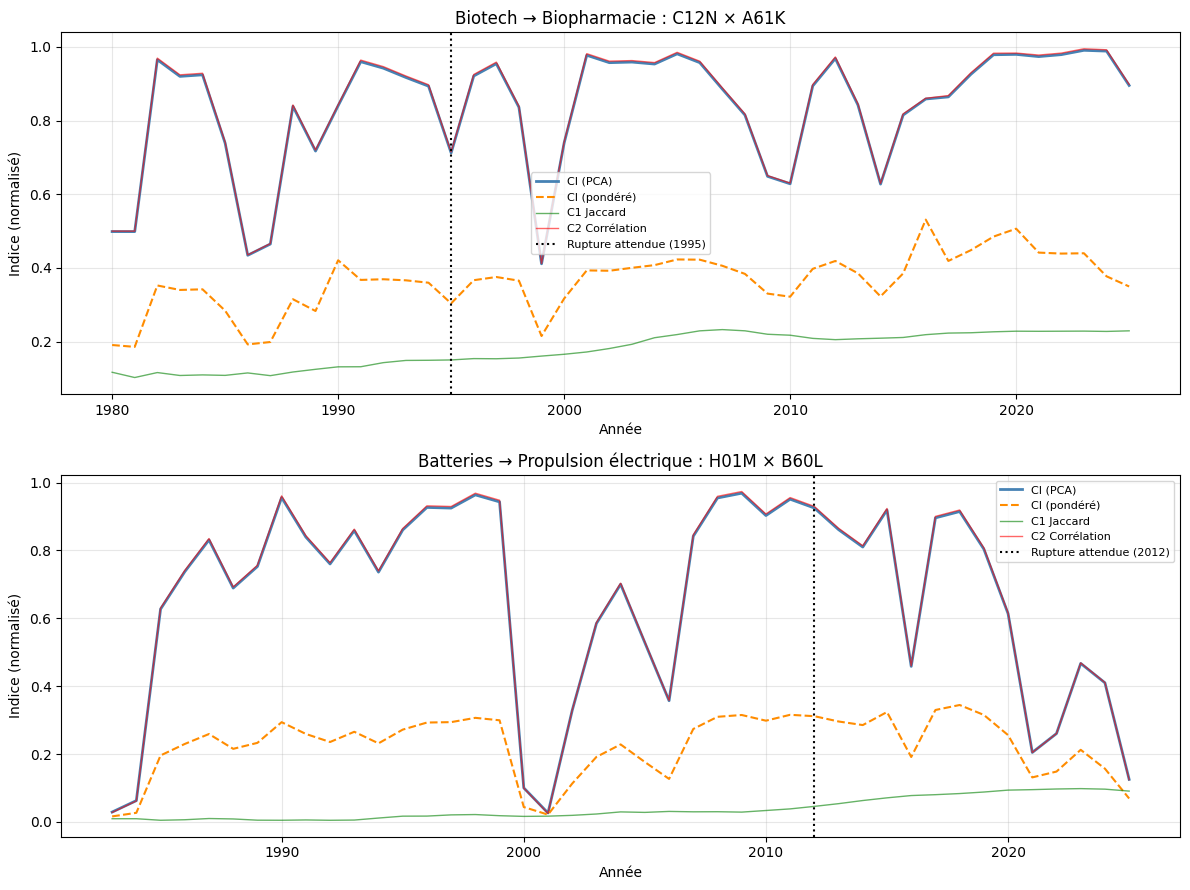

In [14]:
def plot_pair_validation(panel, ci, cj, label, expected_break, ax=None):
    """Trace l'évolution de CI_pca pour une paire donnée."""
    mask = (
        ((panel["cpc_i"] == ci) & (panel["cpc_j"] == cj)) |
        ((panel["cpc_i"] == cj) & (panel["cpc_j"] == ci))
    )
    sub = panel[mask].sort_values("year")

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(sub["year"], sub["CI_pca"],     label="CI (PCA)",      color="steelblue",  lw=2)
    ax.plot(sub["year"], sub["CI_weighted"],label="CI (pondéré)",  color="darkorange", lw=1.5, ls="--")
    ax.plot(sub["year"], sub["C1_jaccard"], label="C1 Jaccard",    color="green",      lw=1, alpha=0.6)
    ax.plot(sub["year"], sub["C2_corr"],    label="C2 Corrélation",color="red",        lw=1, alpha=0.6)
    ax.axvline(expected_break, color="black", ls=":", lw=1.5, label=f"Rupture attendue ({expected_break})")
    ax.set_title(f"{label} : {ci} × {cj}")
    ax.set_xlabel("Année")
    ax.set_ylabel("Indice (normalisé)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return ax


fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_pair_validation(panel, "C12N", "A61K",
                     "Biotech → Biopharmacie", expected_break=1995, ax=axes[0])
plot_pair_validation(panel, "H01M", "B60L",
                     "Batteries → Propulsion électrique", expected_break=2012, ax=axes[1])
plt.tight_layout()
plt.savefig("validation_ground_truth.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Analyse des redondances entre composantes

On vérifie que les 4 composantes apportent bien des informations distinctes
(matrice de corrélation et scatter plots).

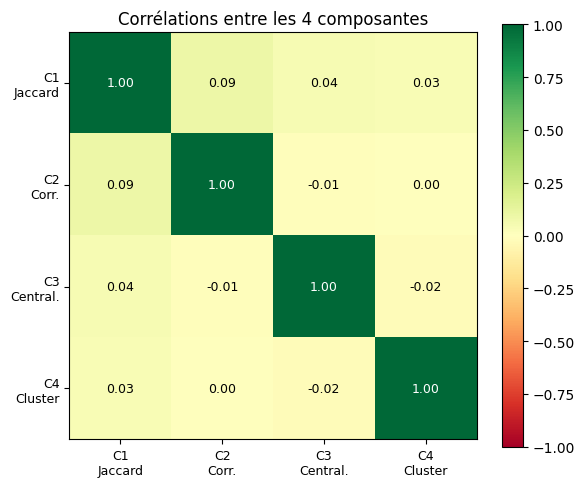


Si C1 et C2 sont très corrélées (> 0.8), envisager de les fusionner.


In [15]:
# ── matrice de corrélation entre composantes ─────────────────────────────────
corr_matrix = panel[norm_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(norm_cols)))
ax.set_yticks(range(len(norm_cols)))
labels_short = ["C1\nJaccard", "C2\nCorr.", "C3\nCentral.", "C4\nCluster"]
ax.set_xticklabels(labels_short, fontsize=9)
ax.set_yticklabels(labels_short, fontsize=9)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="black" if abs(corr_matrix.iloc[i,j]) < 0.7 else "white")
ax.set_title("Corrélations entre les 4 composantes")
plt.tight_layout()
plt.savefig("correlation_composantes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSi C1 et C2 sont très corrélées (> 0.8), envisager de les fusionner.")

---
## Top convergences par année

On identifie les paires les plus convergentes pour chaque période
(utile pour l'analyse économique et la présentation des résultats).

In [16]:
def top_convergences(panel, year, n=15):
    """Retourne les n paires les plus convergentes à une année donnée."""
    return (
        panel[panel["year"] == year]
        .nlargest(n, "CI_pca")[["cpc_i", "cpc_j", "CI_pca",
                                  "C1_jaccard", "C2_corr",
                                  "C3_centrality", "C4_cluster"]]
        .reset_index(drop=True)
    )

# exemples pour 3 années clés
for yr in [1995, 2010, 2020]:
    print(f"\n── Top 10 convergences en {yr} ──────────────────────────────")
    display(top_convergences(panel, yr, n=10))


── Top 10 convergences en 1995 ──────────────────────────────


,cpc_i,cpc_j,CI_pca,C1_jaccard,C2_corr,C3_centrality,C4_cluster
0,C09K,G21K,0.994809,0.031399,0.999792,0.037497,0.032938
1,C01P,Y10S,0.994339,0.005380,0.999827,0.188708,0.000000
2,E21D,F05C,0.993903,0.003780,0.999014,0.007774,0.032938
3,C02F,E03F,0.993226,0.001764,0.998447,0.029437,0.000000
4,B65G,F16L,0.992820,0.004630,0.998027,0.068717,0.032938
5,C10M,E04G,0.992721,0.001655,0.997858,0.018244,0.032938
6,E03B,E03F,0.992641,0.023344,0.997669,0.005557,0.000000
7,A63F,G02C,0.992284,0.004708,0.997440,0.007877,0.000000
8,D04B,G05B,0.992195,0.004008,0.997330,0.028355,0.032938
9,E21D,F16B,0.992180,0.018282,0.997201,0.018214,0.032938



── Top 10 convergences en 2010 ──────────────────────────────


,cpc_i,cpc_j,CI_pca,C1_jaccard,C2_corr,C3_centrality,C4_cluster
0,B23K,C22F,0.994813,0.014810,0.999938,0.019679,0.000000
1,H01M,Y02E,0.994762,0.584433,0.996364,0.199640,0.000000
2,A41D,H01M,0.994263,0.000229,0.999537,0.049680,0.000000
3,G01F,H01M,0.994196,0.000483,0.999479,0.056075,0.000000
4,H01H,H04Q,0.994152,0.004156,0.999350,0.022768,0.000000
5,G01C,Y04S,0.993885,0.000894,0.998839,0.020360,0.139380
6,F21W,G08B,0.993675,0.008084,0.998831,0.015248,0.000000
7,G06Q,G07F,0.993452,0.222185,0.996945,0.040121,0.139380
8,B44B,C14C,0.993300,0.010130,0.997990,0.002146,0.227986
9,C11D,Y10S,0.993110,0.002496,0.998481,0.117143,0.000000



── Top 10 convergences en 2020 ──────────────────────────────


,cpc_i,cpc_j,CI_pca,C1_jaccard,C2_corr,C3_centrality,C4_cluster
0,C10M,C10N,0.998924,0.947353,0.997725,0.019649,0.030834
1,F03D,F05B,0.998143,0.687298,0.998235,0.079609,0.333181
2,F01D,F02C,0.995805,0.317996,0.999129,0.153052,0.000000
3,F04D,F05D,0.995669,0.225466,0.999656,0.175045,0.000000
4,F01D,F05D,0.995315,0.720162,0.996050,0.225276,0.000000
5,F21K,Y10T,0.995309,0.001255,0.999310,0.096536,0.725246
6,A24B,A24F,0.995218,0.323274,0.996917,0.024699,0.725246
7,G06Q,H04L,0.994773,0.118954,0.999695,0.299303,0.000000
8,A46B,Y10S,0.994638,0.003002,0.998539,0.049264,0.725246
9,A63H,G06K,0.994417,0.001640,0.999640,0.025991,0.000000


---
## Évolution temporelle de l'indice agrégé

On représente l'évolution du CI moyen par année (toutes paires confondues)
pour avoir une vue macroscopique des vagues d'innovation.

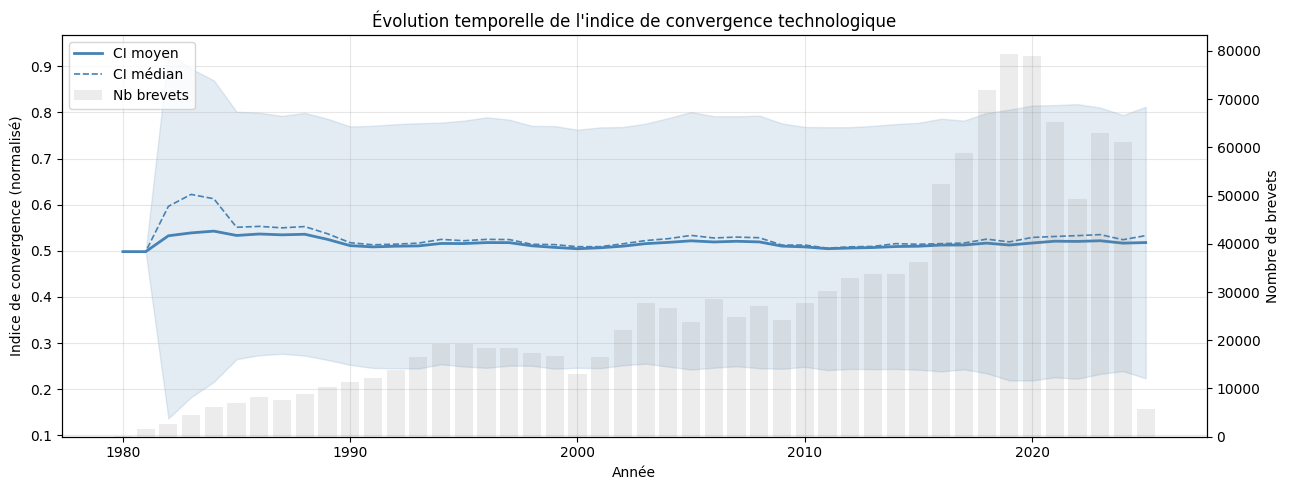

In [17]:
# ── série temporelle agrégée ─────────────────────────────────────────────────
# Normalisation par le nombre de brevets (correction biais de volume)
yearly_patents = pd.Series(brevet_count_by_year).rename("n_patents")

CI_time = (
    panel.groupby("year")["CI_pca"]
    .agg(["mean", "median", "std"])
    .join(yearly_patents)
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.fill_between(
    CI_time.index,
    CI_time["mean"] - CI_time["std"],
    CI_time["mean"] + CI_time["std"],
    alpha=0.15, color="steelblue"
)
ax1.plot(CI_time.index, CI_time["mean"],   label="CI moyen",   color="steelblue", lw=2)
ax1.plot(CI_time.index, CI_time["median"], label="CI médian",  color="steelblue", lw=1.2, ls="--")
ax2.bar(CI_time.index, CI_time["n_patents"], alpha=0.15, color="gray", label="Nb brevets")

ax1.set_xlabel("Année")
ax1.set_ylabel("Indice de convergence (normalisé)")
ax2.set_ylabel("Nombre de brevets")
ax1.set_title("Évolution temporelle de l'indice de convergence technologique")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("CI_temporal_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Export final

In [18]:
# ── export ────────────────────────────────────────────────────────────────────
cols_export = [
    "cpc_i", "cpc_j", "year",
    "C1_jaccard", "C2_corr", "C3_centrality", "C4_cluster",
    "CI_pca", "CI_weighted",
    "jaccard", "p_j_given_i", "p_i_given_j",
    "rolling_corr", "n_cooc"
]
panel[cols_export].to_parquet("indice_convergence_final.parquet", index=False)
panel[cols_export].to_csv("indice_convergence_final.csv", index=False)

print("Fichiers exportés :")
print("  → indice_convergence_final.parquet")
print("  → indice_convergence_final.csv")
print(f"  → {len(panel):,} lignes, {panel['year'].nunique()} années")
panel[cols_export].describe()

Fichiers exportés :
  → indice_convergence_final.parquet
  → indice_convergence_final.csv
  → 1,382,733 lignes, 46 années


,year,C1_jaccard,C2_corr,C3_centrality,C4_cluster,CI_pca,CI_weighted,jaccard,p_j_given_i,p_i_given_j,rolling_corr,n_cooc
count,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06,1.382733e+06
mean,2.009459e+03,6.778723e-03,5.175411e-01,4.079583e-02,3.186099e-02,5.154951e-01,1.705732e-01,6.037312e-03,2.347720e-02,1.769429e-02,3.508228e-02,1.822492e+01
std,1.155130e+01,2.080653e-02,2.775867e-01,4.595729e-02,1.281913e-01,2.758105e-01,8.690170e-02,1.844817e-02,5.921552e-02,4.860916e-02,5.551733e-01,1.245970e+02
min,1.980000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.032922e-04,2.693675e-05,2.977342e-05,2.796030e-05,-9.999999e-01,1.000000e+00
25%,2.001000e+03,7.371168e-04,2.806562e-01,1.373353e-02,0.000000e+00,2.801128e-01,9.775988e-02,6.805036e-04,2.028398e-03,1.390821e-03,-4.386876e-01,1.000000e+00
50%,2.012000e+03,1.889342e-03,5.238848e-01,2.761437e-02,0.000000e+00,5.218102e-01,1.715722e-01,1.702128e-03,6.085193e-03,4.323899e-03,4.776971e-02,3.000000e+00
75%,2.019000e+03,5.239886e-03,7.583217e-01,5.167045e-02,0.000000e+00,7.547421e-01,2.424724e-01,4.672897e-03,1.869159e-02,1.383485e-02,5.166434e-01,8.000000e+00
max,2.025000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,7.261803e-01,8.866799e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.044700e+04
